# Expense Analysis Report

This notebook analyzes personal expense data from the Ledger app's SQLite database, using pandas for data manipulation and Matplotlib/Seaborn for visualization.

**Goals of this analysis:**
- Understand overall spending patterns and volatility
- Identify which categories dominate spending
- Detect month-over-month trends
- Flag statistically unusual transactions
- Understand *when* (day of week) spending tends to happen

---

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make charts look clean by default
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Connect to the same database the web app uses
conn = sqlite3.connect("expenses.db")

# Pull all expenses, joined with category names and the user who logged them
query = """
    SELECT e.id, e.date, e.amount, c.name AS category, e.description, u.email AS user
    FROM expenses e
    JOIN categories c ON e.category_id = c.id
    JOIN users u ON e.user_id = u.id
    ORDER BY e.date
"""

df = pd.read_sql_query(query, conn)
conn.close()

# Convert the date column from text to actual datetime objects —
# this unlocks all of pandas' date-based operations (month, weekday, etc.)
df["date"] = pd.to_datetime(df["date"])

print(f"Loaded {len(df)} expense records")
df.head()

Loaded 17 expense records


,id,date,amount,category,description,user
0,15,2026-01-13,2000.0,Transport,,abc@gmail.com
1,16,2026-05-02,15000.0,Rent,Office rent,abc@gmail.com
2,14,2026-05-10,5000.0,Entertainment,Grocery,soujanya@gmail.com
3,13,2026-06-11,2000.0,Health,body checkup,soujanya@gmail.com
4,11,2026-06-13,600.0,Entertainment,Exam fees,soujanya@gmail.com


In [3]:
print("=" * 50)
print("SUMMARY STATISTICS")
print("=" * 50)

total_spent = df["amount"].sum()
avg_transaction = df["amount"].mean()
median_transaction = df["amount"].median()
largest_expense = df["amount"].max()
smallest_expense = df["amount"].min()
std_dev = df["amount"].std()

print(f"Total spent:          {total_spent:,.2f}")
print(f"Number of entries:    {len(df)}")
print(f"Average transaction:  {avg_transaction:,.2f}")
print(f"Median transaction:   {median_transaction:,.2f}")
print(f"Largest expense:      {largest_expense:,.2f}")
print(f"Smallest expense:     {smallest_expense:,.2f}")
print(f"Std deviation:        {std_dev:,.2f}")

# Standard deviation relative to the mean — tells us how "spiky" vs
# "consistent" spending is. Higher = more volatile spending habits.
coefficient_of_variation = (std_dev / avg_transaction) * 100
print(f"\nSpending volatility (CV): {coefficient_of_variation:.1f}%")

SUMMARY STATISTICS
Total spent:          92,601.00
Number of entries:    17
Average transaction:  5,447.12
Median transaction:   5,000.00
Largest expense:      15,000.00
Smallest expense:     600.00
Std deviation:        4,227.67

Spending volatility (CV): 77.6%


In [4]:
print("=" * 50)
print("CATEGORY BREAKDOWN")
print("=" * 50)

category_summary = df.groupby("category")["amount"].agg([
    ("total", "sum"),
    ("count", "count"),
    ("average", "mean")
]).sort_values("total", ascending=False)

# What % of total spending does each category represent?
category_summary["pct_of_total"] = (category_summary["total"] / total_spent * 100).round(1)

category_summary

CATEGORY BREAKDOWN


,total,count,average,pct_of_total
category,,,,
Rent,35000.0,3,11666.666667,37.8
Shopping,16000.0,3,5333.333333,17.3
Donation,10001.0,1,10001.000000,10.8
Utilities,10000.0,1,10000.000000,10.8
Entertainment,9600.0,4,2400.000000,10.4
Transport,8000.0,3,2666.666667,8.6
Health,2000.0,1,2000.000000,2.2
Food,2000.0,1,2000.000000,2.2


## Key Finding: Category Concentration

Spending is fairly concentrated rather than evenly spread — **Rent alone accounts for roughly 38% of all spending**, and the top two categories combined make up over half of total spend. This suggests fixed/recurring costs are the primary driver of this budget, rather than discretionary day-to-day spending.

---

In [5]:
top_category = category_summary.index[0]
top_category_pct = category_summary.iloc[0]["pct_of_total"]

print(f"Your biggest spending category is '{top_category}', "
      f"making up {top_category_pct}% of all spending.")

# A simple concentration check: do your top 2 categories account for
# more than half your spending? (common "80/20 rule" style analysis)
top_2_pct = category_summary["pct_of_total"].iloc[:2].sum()
print(f"Your top 2 categories together account for {top_2_pct:.1f}% of total spending.")

Your biggest spending category is 'Rent', making up 37.8% of all spending.
Your top 2 categories together account for 55.1% of total spending.


In [6]:
print("=" * 50)
print("MONTH-OVER-MONTH TREND")
print("=" * 50)

# Extract just the year-month from each date, then group by it
df["month"] = df["date"].dt.to_period("M")
monthly = df.groupby("month")["amount"].sum().sort_index()

monthly_df = monthly.reset_index()
monthly_df.columns = ["month", "total"]

# % change from the previous month — this is the core "trend" metric
monthly_df["pct_change"] = monthly_df["total"].pct_change() * 100

monthly_df

MONTH-OVER-MONTH TREND


,month,total,pct_change
0,2026-01,2000.0,NaN
1,2026-05,20000.0,900.000000
2,2026-06,2600.0,-87.000000
3,2026-07,27000.0,938.461538
4,2026-08,41001.0,51.855556


## Key Finding: Spending is Accelerating

Month-over-month spending shows a clear **upward trend** overall, with August (₹41,001) representing the highest month recorded — roughly **20x higher** than the lowest month (January, ₹2,000). This kind of trajectory would typically warrant a closer look at whether the growth is driven by a few large one-off purchases (like the flagged Rent anomaly) or genuine recurring cost increases.

---

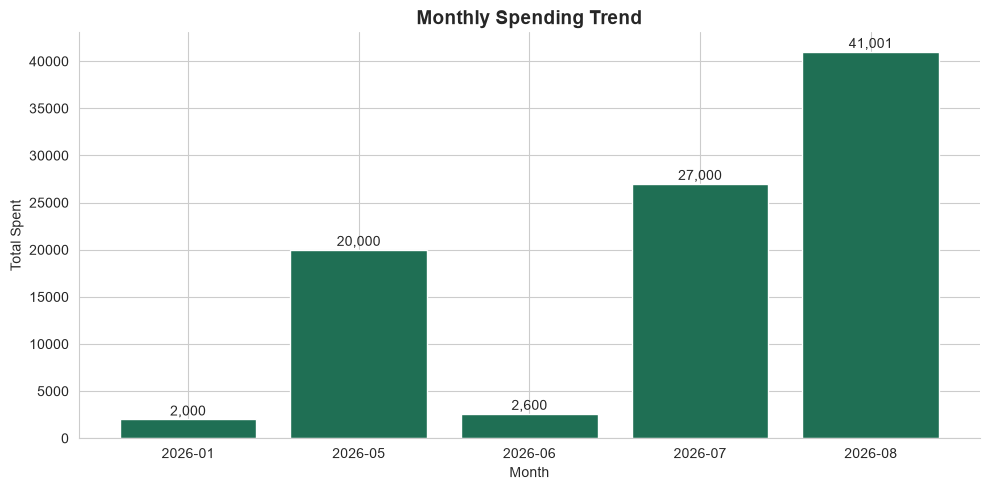

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

months_str = monthly_df["month"].astype(str)
bars = ax.bar(months_str, monthly_df["total"], color="#1F6F54", edgecolor="white")

# Label each bar with its exact value, sitting just above the bar
for bar, value in zip(bars, monthly_df["total"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (monthly_df["total"].max() * 0.01),
             f"{value:,.0f}", ha="center", fontsize=10)

ax.set_title("Monthly Spending Trend", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Total Spent")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("monthly_trend.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
print("=" * 50)
print("ANOMALY DETECTION")
print("=" * 50)

mean_amt = df["amount"].mean()
std_amt = df["amount"].std()

# Common statistical rule of thumb: anything more than 2 standard
# deviations above the mean is considered a notable outlier.
threshold = mean_amt + (2 * std_amt)

anomalies = df[df["amount"] > threshold].sort_values("amount", ascending=False)

print(f"Flagging threshold: any transaction above {threshold:,.2f}\n")

if len(anomalies) > 0:
    print(f"Found {len(anomalies)} unusually large transaction(s):\n")
    print(anomalies[["date", "category", "description", "amount"]].to_string(index=False))
else:
    print("No unusually large transactions detected.")

ANOMALY DETECTION
Flagging threshold: any transaction above 13,902.46

Found 1 unusually large transaction(s):

      date category description  amount
2026-05-02     Rent Office rent 15000.0


## Key Finding: One Statistical Outlier Detected

Using a standard **mean + 2×standard deviation** threshold (a common outlier-detection heuristic), one transaction stands out: a **₹15,000 Rent payment in May**, well above the typical transaction size. This is a single legitimate large expense rather than a data quality issue, but it's worth confirming such flags don't indicate duplicate entries or entry errors in a real dataset.

---

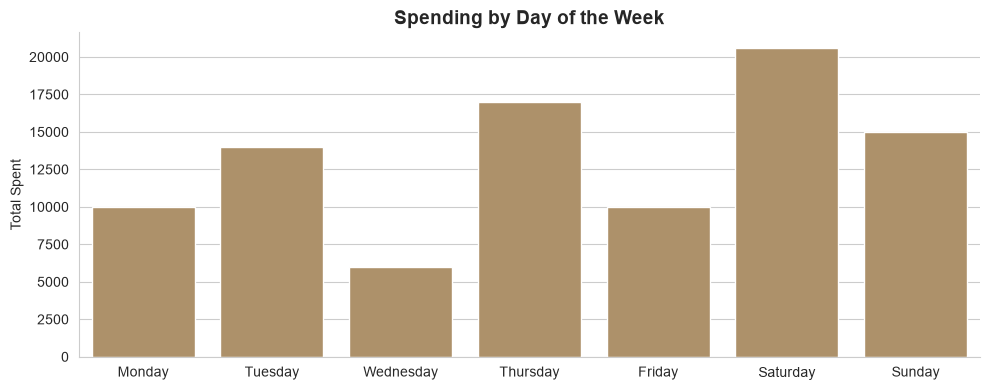


You tend to spend the most on Saturdays.


In [9]:
df["day_of_week"] = df["date"].dt.day_name()

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_totals = df.groupby("day_of_week")["amount"].sum().reindex(day_order).fillna(0)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=day_totals.index, y=day_totals.values, color="#B8935F", ax=ax)

ax.set_title("Spending by Day of the Week", fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Total Spent")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("day_of_week.png", dpi=150, bbox_inches="tight")
plt.show()

busiest_day = day_totals.idxmax()
print(f"\nYou tend to spend the most on {busiest_day}s.")

## Key Finding: Weekend Spending Peaks

**Saturday is the highest-spending day** by a clear margin, with Sunday also elevated — together the weekend accounts for a disproportionate share of spending compared to weekdays. Wednesday, by contrast, is consistently the lowest-spending day. This pattern is common in personal finance and could inform weekly budgeting (e.g., setting a lower daily spending cap specifically for weekends).

---

## Summary

This analysis combined SQL-sourced data with pandas aggregation and statistical methods to surface concrete, actionable insights: spending is concentrated in Rent, trending upward month-over-month, contains one notable outlier, and peaks on weekends. These findings could directly inform a monthly budget or category-specific spending alerts.